# Return convergence against training time — one DreamerV3 hyperparameter sweep

Same curves as [`sps_train_return_convergence_snapshots.ipynb`](sps_train_return_convergence_snapshots.ipynb),
plotted against **training time instead of training episodes**. The episode axis answers
*how sample-efficient* a configuration is; this one answers *how fast it actually learns on the
machine*, which is the axis a DreamerV3 sweep needs — `training_ratio`, `batch_size_B`,
`batch_length_T` and `horizon_H` all buy sample efficiency with compute per env step, so two
configurations that look equal per episode can be hours apart per unit of return.

## Where the time axis comes from

Every run keeps two independent records of elapsed time, and a third axis is derived from the first
by correcting it for how fast the machine was. `TIME_SOURCE` selects which one the figures use; the
table below prints all three, so the choice stays checkable.

| `TIME_SOURCE` | Source | What it counts |
|---|---|---|
| `"progress_norm"` (default) | `time_total_s`, each iteration rescaled by its own `env_runners/env_step_timer` | Training-iteration time at one fixed machine speed |
| `"progress"` | `time_total_s` column of the tune trial's `progress.csv`, one row per iteration | Time inside the training iterations, as the machine ran that day |
| `"events"` | `wall_time` field of each TBX event, minus the run's first event | Everything between the first and the last logged iteration |

`time_total_s` is Tune's own accumulator: `Trainable.train()` measures `time_this_iter_s` around
`self.step()` (`ray/tune/trainable/trainable.py:326`, `:344-348` of the installed Ray 2.52.1) and
adds it to `_time_total` (`:348`), which is what lands in the result dict as `time_total_s`
(`:227`). It therefore **excludes** the driver setup before iteration 1 (Ray init, env
construction, CSV parsing), checkpoint writing and Tune's own result handling, and it **survives
a `--restore` resume**, because the accumulator is reloaded from the checkpoint (`:539`) while
`time_since_restore` restarts at zero (`:540`).

The event `wall_time` is the opposite trade: it includes the per-iteration overhead outside
`step()` (checkpointing, logging), but it would also swallow a queue gap if a run were ever
suspended and resumed. The `train_hours` / `wall_hours` columns of the table below quantify the
gap for these runs.

The TBX step of these runs **is** the training iteration (`step 1 … N`, one point per row of
`progress.csv`), so the join is exact: `_curve_seconds` maps each curve point's step through the
run's own `(training_iteration → elapsed seconds)` table. A log written in env-step units instead
is converted to iterations first, using the same per-run scale factors as the sibling notebook.

## Why the default axis is the normalised one

Raw wall clock is not a cost measure across these runs. They went to two different SLURM nodes at
different times (`node` in the hardware table), each job sharing its node — 3 CPUs and a 4864 MiB
MIG slice — with whatever else was running, and a busy node stretches every part of an iteration.
On a raw wall-clock axis that is indistinguishable from a more expensive configuration, and in this
sweep it is not a hypothetical: raw seconds per iteration put `v7` (`r10`, 84 000 gradient updates)
at 6.82 **ahead of** `v7_lti` (`r5`, 42 000 updates) at 7.82 — an ordering `training_ratio` cannot
produce.

`progress_norm` removes that. `env_runners/env_step_timer` is used as a machine-speed probe: an EMA
(coefficient 0.01, `ray/rllib/utils/metrics/stats.py:175`) over single `self.env.step()` calls
(`ray/rllib/env/env_runner.py:253`), covering the component loops, the pandas row lookups of the
outer statesources and the numpy work of the wrapper chain — CPU only, with no policy forward
(timed separately as `rlmodule_inference_timer`) and no GPU. Each iteration's duration is divided
by that iteration's own env-step cost, multiplied by `REFERENCE_ENV_STEP_MS` and re-accumulated;
the result is the `progress_norm` axis and the `*_norm` columns of the tables.

What licenses the probe is not that it is cheap but that it is **configuration-independent**: none
of `batch_size_B` / `batch_length_T` / `horizon_H` / `training_ratio` reaches `env.step()`, and the
env, wrappers, episode length and data schedule are identical across this sweep — so a difference
in it is the machine, not the run. It is also local in time at this episode length: one training
iteration is 288 env steps and `0.99**288 = 0.055`, i.e. ~94 % of the reported EMA's weight is on
steps taken inside the reporting iteration.

*Limits.* The correction assumes an iteration's wall time scales with its env-step cost, i.e. that
a slowed machine slows the GPU-side learner work in the same proportion as the CPU-side sampling;
it is calibrated within a run, and comparing across nodes additionally assumes their single-thread
speed is captured by `env.step()`, which nothing in these logs can confirm. Read the corrected
hours as an estimate. What the sweep does show is that it removes the contradiction: after the
correction every `r10` / `r5` pair costs more per iteration at `r10`, and none does before it.
`REFERENCE_ENV_STEP_MS` is a free scale — only ratios between runs carry meaning — and at 1.0 the
normalised hours stay close to the wall clock of an uncontended run here.

## Comparability of a training-time axis

The correction handles machine *speed*; it cannot handle a different *allocation*, so the notebook
also prints a hardware table (SLURM CPUs, node, MIG slice memory, `num_env_runners` from
`param_space.json`) parsed from each run's SLURM `.out` banner. Check it before reading the
figures: a run that got a different allocation is not on the same axis as the rest, however
identical its config.

## Per-snapshot run selection

A snapshot directory can hold several `runs/train_*` directories. Without a `run` key the one
whose event files hold the most bytes wins — which is ambiguous for the un-suffixed snapshot,
whose `runs/` now carries five `--common-seed` seed-sweep runs (`train_20260810_1128*_cseed*`).
Pin it explicitly with `"run": "train_…"` in `SNAPSHOTS`; the resolved run name is printed in the
table for every entry.

In [2]:
# --- Main input ---------------------------------------------------------------------
# The snapshots whose training / in-training-eval return curves are overlaid. Keys per entry:
#   path       snapshot dir (absolute, or relative to the repo root)
#   label      short name shown in the legend and used as the table index
#   color      line colour; snapshots that share a configuration family share a colour
#   linestyle  matplotlib linestyle; the secondary encoding that separates same-colour entries
#   run        optional runs/<name> to pin; without it the run holding the most event bytes wins
ALGO_TYPE = "dreamerv3"
SNAPSHOT_PREFIX = "snapshots/20260704_183007_sta_lin_battery_only_price_dreamerv3"

SNAPSHOTS = [
    # The un-suffixed snapshot holds five --common-seed runs; pinned so the entry is reproducible.
    {"path": f"{SNAPSHOT_PREFIX}",          "label": "v1 (abort.)",       "color": "#2a78d6", "linestyle": "-",
     "run": "train_20260810_112805_cseed42"},
    {"path": f"{SNAPSHOT_PREFIX}_lo_tr",    "label": "v1 (compl.)", "color": "#2a78d6", "linestyle": "--"},
    {"path": f"{SNAPSHOT_PREFIX}_v2",       "label": "v2",       "color": "#eb6834", "linestyle": "-"},
    # _v2_long_H records the same four swept values as _v2 in its param_space.json — the intended
    # longer horizon never reached the frozen config, so it is left out of the sweep.
    # {"path": f"{SNAPSHOT_PREFIX}_v2_long_H", "label": "v2_long_H", "color": "#eb6834", "linestyle": "--"},
    {"path": f"{SNAPSHOT_PREFIX}_v3_la_ti", "label": "v3",       "color": "#1baf7a", "linestyle": "-"},
    {"path": f"{SNAPSHOT_PREFIX}_v3",       "label": "v3_lti",   "color": "#1baf7a", "linestyle": "--"},
    {"path": f"{SNAPSHOT_PREFIX}_v4",       "label": "v4",       "color": "#eda100", "linestyle": "-"},
    {"path": f"{SNAPSHOT_PREFIX}_v5",       "label": "v5",       "color": "#e87ba4", "linestyle": "-"},
    {"path": f"{SNAPSHOT_PREFIX}_v6",       "label": "v6",       "color": "#008300", "linestyle": "-"},
    {"path": f"{SNAPSHOT_PREFIX}_v6_lti",   "label": "v6_lti",   "color": "#008300", "linestyle": "--"},
    {"path": f"{SNAPSHOT_PREFIX}_v7",       "label": "v7",       "color": "#4a3aa7", "linestyle": "-"},
    {"path": f"{SNAPSHOT_PREFIX}_v7_lti",   "label": "v7_lti",   "color": "#4a3aa7", "linestyle": "--"},
    {"path": f"{SNAPSHOT_PREFIX}_v8",       "label": "v8",       "color": "#e34948", "linestyle": "-"},
    {"path": f"{SNAPSHOT_PREFIX}_v8_lti",   "label": "v8_lti",   "color": "#e34948", "linestyle": "--"},
    {"path": f"{SNAPSHOT_PREFIX}_default",  "label": "default",  "color": "#6c0063", "linestyle": "-"},
]

# A snapshot without any usable training log (e.g. a job still queued) is skipped with a
# warning instead of aborting the notebook. Set False to make it an error.
SKIP_SNAPSHOTS_WITHOUT_LOG = True

# The two RLlib return scalars, plotted as the training / eval series.
TRAIN_METRIC = "ray/tune/env_runners/episode_return_mean"
EVAL_METRIC = "ray/tune/evaluation/env_runners/episode_return_mean"

# Which elapsed-time record drives the x-axis:
#   "progress_norm"  time_total_s with every iteration rescaled to REFERENCE_ENV_STEP_MS by its own
#                    env-step cost — training time at one fixed machine speed (see the intro)
#   "progress"       Tune's raw time_total_s per iteration — time inside the training iterations
#   "events"         TBX event wall_time minus the run's first event — includes per-iteration overhead
# All three are put in the table either way, so the effect of the choice stays visible.
TIME_SOURCE = "progress_norm"

# Reference machine speed the normalised axis is expressed in, in milliseconds per env.step().
# Only ratios between runs carry meaning, so the value is a free scale; 1.0 keeps the normalised
# hours close to the wall clock of an uncontended run in this sweep.
REFERENCE_ENV_STEP_MS = 1.0

TIME_UNIT = "hours"      # "hours" or "minutes"
LOG_TIME_AXIS = False    # log x, for reading the early phase where the curves separate first
TIME_LIMIT = None        # cut the x-axis at this many TIME_UNIT (None = the longest run)

# The param_space.json keys that differ across these snapshots; shown in the table and, with
# LABEL_WITH_PARAMS, appended to the legend entry. Read from each run's own param_space.json.
PARAM_KEYS = ("batch_size_B", "batch_length_T", "horizon_H", "training_ratio")
LABEL_WITH_PARAMS = True

# TensorBoard-style EWMA weight in [0, 1): 0 = raw, higher = smoother. The raw curve is drawn
# faint behind the smoothed one when SHOW_RAW is True.
SMOOTHING = 0.99
SHOW_RAW = True

# The training and eval figures are separate; SHARE_Y puts them on one common y-range so they
# stay comparable side by side in the thesis.
SHARE_Y = True

# Clips the y-axis at this percentile of the drawn values, so a single early collapse (the
# harsh first-iteration returns) does not squash the converged part of every curve.
# Set to None to show the full range.
Y_CLIP_PERCENTILE = None

# "How fast" in one number: the time each run needs to reach these fractions of the best final
# return in the sweep (THRESHOLD_SERIES picks which series defines and is measured against that
# level). Fractions assume the reference level is positive — the absolute targets are printed.
THRESHOLD_SERIES = "eval"
THRESHOLD_FRACTIONS = (0.5, 0.75, 0.9)

# What counts as "reached":
#   "sustained"  the point from which the smoothed curve never drops below the level again —
#                a run that touches the level and then collapses does not count as having got there
#   "first"      the first crossing, whatever happens afterwards
CROSSING = "sustained"

# Figure sizes in inches. Every plot function also takes figsize=… to override its default for one
# call, so a figure can be re-cut for a slide or a two-column page without touching the others.
# The level figure's height is derived from the number of snapshots unless a height is given:
# LEVELS_ROW_HEIGHT per row plus LEVELS_HEIGHT_PAD for the axis labels and the legend.
FIGSIZE_CURVE = (9.0, 6.5)
FIGSIZE_LEVELS = (9.0, None)
LEVELS_ROW_HEIGHT = 0.45
LEVELS_HEIGHT_PAD = 2.2
FIGSIZE_SCATTER = (8.0, 6.0)

# The allocation table below is a precondition check, not a result; with it False only its
# one-line verdict is printed.
SHOW_HARDWARE_TABLE = True

# Filename prefix for the saved figures.
OUT_PREFIX = f"{ALGO_TYPE}_snapshots_time"
EPISODE_LENGTH = 288  # env_meta.EPISODE_LENGTH of the trial; only used for env-step-indexed logs

In [3]:
import csv
import hashlib
import json
import re
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from tensorboard.backend.event_processing.event_file_loader import EventFileLoader
from tensorboard.util import tensor_util


# Walk upwards from the cwd until the directory containing snapshots/ is found, so the
# notebook runs both from thesis_eval/ and from the repo root.
def _find_repo_root() -> Path:
    for candidate in (Path.cwd(), *Path.cwd().parents):
        if (candidate / "snapshots").is_dir():
            return candidate
    raise FileNotFoundError("No 'snapshots/' directory found upwards of the cwd — run inside the repo.")


REPO_ROOT = _find_repo_root()

# VS Code exposes the notebook path; a plain Jupyter kernel starts in the notebook's directory.
NB_DIR = Path(globals()["__vsc_ipynb_file__"]).parent if "__vsc_ipynb_file__" in globals() else Path.cwd()
# Own cache dir: these entries carry the event wall_time, which the sibling notebook's cache lacks.
CACHE_DIR = NB_DIR / ".tb_time_cache"
CACHE_SCHEMA = "v1-wall_time"

TIME_DIVISOR = {"hours": 3600.0, "minutes": 60.0}
TIME_SOURCES = ("progress", "progress_norm", "events")
# Axis label per time source: the normalised axis is no longer wall clock, and the figure axis is the
# only place a reader of the PDF alone can learn that. Kept to the length of the wall-clock label —
# the level and trade-off figures append to it — and without the reference speed, which is a free
# scale anyway (only ratios between runs carry meaning; it is printed below and in the tables).
TIME_SOURCE_LABEL = {
    "progress": "Wall-clock training time",
    "events": "Wall-clock training time",
    "progress_norm": "Normalised training time",
}
TIME_UNIT_SUFFIX = {"hours": "h", "minutes": "min"}


def _time_label(source: str | None = None, unit: str | None = None) -> str:
    """Axis label of one time source, defaulting to the configured TIME_SOURCE / TIME_UNIT."""
    return f"{TIME_SOURCE_LABEL[source or TIME_SOURCE]} ({TIME_UNIT_SUFFIX[unit or TIME_UNIT]})"


# The event files of a snapshot's main RLlib TBX log, oldest first, together with the run and
# tune-trial directory they belong to. `run_name` pins runs/<run_name>; without it the tune trial
# directory holding the most event bytes wins. All event files of that directory are returned,
# because a run resumed via --restore keeps writing into it and its curve is spread over several.
def _snapshot_event_files(snapshot_dir: Path, run_name: str | None = None) -> tuple[list[Path], Path, Path] | None:
    pattern = f"runs/{run_name}/models/**/events.out.tfevents.*" if run_name else "runs/train_*/models/**/events.out.tfevents.*"
    candidates = list(snapshot_dir.glob(pattern))
    if not candidates:
        return None
    by_trial_dir: dict[Path, list[Path]] = {}
    for path in candidates:
        by_trial_dir.setdefault(path.parent, []).append(path)
    trial_dir = max(by_trial_dir, key=lambda directory: sum(p.stat().st_size for p in by_trial_dir[directory]))
    if len(by_trial_dir) > 1:
        others = sorted(str(d.relative_to(snapshot_dir)) for d in by_trial_dir if d != trial_dir)
        print(f"note: {snapshot_dir.name} holds {len(by_trial_dir)} logged trial dirs — "
              f"using the largest, ignoring {others}")
    # runs/train_*/models/... — the run dir is the ancestor directly under runs/.
    run_dir = next(parent for parent in trial_dir.parents if parent.parent.name == "runs")
    return sorted(by_trial_dir[trial_dir], key=lambda path: path.stat().st_mtime), run_dir, trial_dir


# Extracts the requested scalar tags from one snapshot's event files into a long frame
# (tag, step, wall_time, value), caching the result as a CSV keyed by every input file's
# path + size + mtime (so a resumed / still-running log re-parses). wall_time is the event's own
# unix timestamp — the "events" TIME_SOURCE.
def _extract_curves(event_files: list[Path], tags: tuple[str, ...]) -> pd.DataFrame:
    fingerprint = "|".join(
        f"{path}:{path.stat().st_size}:{int(path.stat().st_mtime)}" for path in event_files
    ) + "|" + ",".join(sorted(tags)) + "|" + CACHE_SCHEMA
    cache_path = CACHE_DIR / f"{hashlib.md5(fingerprint.encode()).hexdigest()}.csv"
    if cache_path.exists():
        return pd.read_csv(cache_path)

    rows = []
    for file_order, event_file in enumerate(event_files):
        for event in EventFileLoader(str(event_file)).Load():
            for value in event.summary.value:
                if value.tag not in tags:
                    continue
                # RLlib writes scalars in the tensor field; legacy simple_value is the fallback.
                scalar = float(tensor_util.make_ndarray(value.tensor)) if value.HasField("tensor") else value.simple_value
                rows.append({"tag": value.tag, "step": event.step, "wall_time": event.wall_time,
                             "value": scalar, "file_order": file_order})
    if not rows:
        raise ValueError(f"None of {tags} found in {[str(p) for p in event_files]}")

    curves = (
        pd.DataFrame(rows)
        .sort_values(["tag", "file_order", "step"])
        # Resume overlap: the same step logged again by a later event file wins.
        .drop_duplicates(["tag", "step"], keep="last")
        .sort_values(["tag", "step"])
        .reset_index(drop=True)
    )
    CACHE_DIR.mkdir(exist_ok=True)
    curves.to_csv(cache_path, index=False)
    return curves


# The algorithm-config values Ray was handed, from the run's param_space.json
# (written by run_train_ray.py) — the authoritative record of what a snapshot ran with,
# never the directory name. num_env_runners rides along because it sets the sampling throughput
# and therefore belongs to any wall-clock comparison.
def _run_params(run_dir: Path, keys: tuple[str, ...]) -> dict:
    extra = ("seed", "num_env_runners", "num_learners", "evaluation_interval")
    param_space_path = run_dir / "param_space.json"
    if not param_space_path.is_file():
        print(f"WARNING: {run_dir.name} has no param_space.json — its hyperparameters are unknown")
        return {key: None for key in (*keys, *extra)}
    param_space = json.loads(param_space_path.read_text())
    return {key: param_space.get(key) for key in (*keys, *extra)}


# The columns the env-step probe contributes, in table order: the bare `env_step_ms` is the median,
# the rest carry their statistic as a suffix. A run that held one speed throughout has all of them
# within a few percent of each other; one that changed speed part-way has p5 and p95 in different
# regimes, and a short regime (< 5 % of the iterations) hides from the percentiles but still moves
# mean and std — which is why both are reported. The sibling notebook carries the same statistics
# for the learner timers, which are a cost diagnostic rather than a machine probe.
TIMER_PERCENTILES = (5, 95)


def _timer_stat_keys(prefix: str) -> tuple[str, ...]:
    return (prefix, f"{prefix}_mean", f"{prefix}_std", *(f"{prefix}_p{p}" for p in TIMER_PERCENTILES))


def _timer_stats(values, prefix: str) -> dict:
    """Distribution of one per-iteration timer over a whole run, in milliseconds."""
    keys = _timer_stat_keys(prefix)
    series = np.asarray(values, dtype=float)
    if not series.size:
        return dict.fromkeys(keys, float("nan"))
    quantiles = np.percentile(series, [50, *TIMER_PERCENTILES])
    return {
        prefix: float(quantiles[0]),
        f"{prefix}_mean": float(series.mean()),
        # ddof=1 matches pandas' default, so the value reproduces if recomputed from the CSV.
        f"{prefix}_std": float(series.std(ddof=1)) if series.size > 1 else float("nan"),
        **{f"{prefix}_p{p}": float(q) for p, q in zip(TIMER_PERCENTILES, quantiles[1:])},
    }


# The per-iteration time series of the tune trial — the (training_iteration -> elapsed seconds)
# table every curve point is interpolated through, under both progress-based sources — plus the
# distribution of the env-step probe the normalised one is built on. Only complete rows are kept:
# a run still in progress can leave a torn final line.
#
#   "progress"       Tune's accumulator time_total_s, straight out of the CSV.
#   "progress_norm"  the same run at one fixed machine speed: each iteration's duration (the
#                    increment of time_total_s, so both axes come from one source) is divided by
#                    THAT iteration's own env_step_timer and multiplied by REFERENCE_ENV_STEP_MS,
#                    then re-accumulated. See the intro for what makes the probe a valid one.
#
# An iteration that logged no env-step time is corrected with the run's median instead of its own;
# a run that logs none at all (another algorithm, an older RLlib) leaves the normalised axis NaN
# while the raw ones stay usable.
def _iteration_time_table(trial_dir: Path) -> tuple[np.ndarray, dict[str, np.ndarray], dict]:
    progress_path = trial_dir / "progress.csv"
    if not progress_path.is_file():
        raise FileNotFoundError(f"No progress.csv next to the event file in {trial_dir}")
    iterations, seconds, probe_ms = [], [], []
    with progress_path.open() as handle:
        for row in csv.DictReader(handle):
            if not (row.get("training_iteration") and row.get("time_total_s")):
                continue
            iterations.append(float(row["training_iteration"]))
            seconds.append(float(row["time_total_s"]))
            env_step_seconds = row.get("env_runners/env_step_timer")
            probe_ms.append(1000.0 * float(env_step_seconds)
                            if env_step_seconds and float(env_step_seconds) > 0.0 else float("nan"))
    if not iterations:
        raise ValueError(f"No complete row in {progress_path}")

    iterations, seconds, probe_ms = np.asarray(iterations), np.asarray(seconds), np.asarray(probe_ms)
    # time_this_iter_s, recovered as the increment of Tune's accumulator; iteration 1 spans from 0.
    durations = np.diff(seconds, prepend=0.0)
    measured = np.isfinite(probe_ms)
    if measured.any():
        filled = np.where(measured, probe_ms, np.median(probe_ms[measured]))
        normalised = np.cumsum(durations * REFERENCE_ENV_STEP_MS / filled)
        if not measured.all():
            print(f"note: {trial_dir.name}: {int((~measured).sum())} of {measured.size} iterations logged no "
                  f"env-step time — corrected with the run's median")
    else:
        print(f"WARNING: {trial_dir.name} logs no env_runners/env_step_timer — its normalised axis is undefined")
        normalised = np.full(seconds.shape, float("nan"))
    return iterations, {"progress": seconds, "progress_norm": normalised}, _timer_stats(probe_ms[measured], "env_step_ms")


# Step-axis unit and x-axis conversion factors from the last row of the trial's progress.csv,
# so a run that is still training works too (result_0.json only appears once the tuner finishes).
def _run_step_scales(trial_dir: Path, last_step: float) -> dict:
    progress_path = trial_dir / "progress.csv"
    columns = ("training_iteration", "num_env_steps_sampled_lifetime", "env_runners/num_episodes_lifetime",
               "time_total_s")
    with progress_path.open() as handle:
        last_row = None
        for row in csv.DictReader(handle):
            if all(row.get(column) for column in columns):
                last_row = row
    if last_row is None:
        raise ValueError(f"No complete row in {progress_path}")
    iterations = float(last_row["training_iteration"])
    env_steps = float(last_row["num_env_steps_sampled_lifetime"])
    episodes = float(last_row["env_runners/num_episodes_lifetime"])
    # Iteration-indexed vs env-step-indexed logs differ by ~3 orders of magnitude, so the
    # last logged step identifies the unit unambiguously.
    if abs(last_step - iterations) <= abs(last_step - env_steps):
        return {"step_unit": "iteration", "episodes_per_step": episodes / iterations,
                "env_steps_per_step": env_steps / iterations, "iterations": iterations}
    return {"step_unit": "env_step", "episodes_per_step": 1.0 / EPISODE_LENGTH, "env_steps_per_step": 1.0,
            "iterations": iterations}


# The allocation a run got, from the SLURM banner its .out log opens with (slurm_train_ray.sh
# prints SLURM_CPUS_PER_TASK / Node and an nvidia-smi dump; the MIG row carries the slice's
# memory). Training-time curves are only comparable across runs whose rows agree here.
def _hardware_info(run_dir: Path) -> dict:
    logs = sorted(run_dir.glob("slurm_*.out"))
    if not logs:
        return {"cpus": None, "node": None, "gpu_MiB": None}
    head = logs[0].open(errors="ignore").read(8192)
    cpus = re.search(r"SLURM_CPUS_PER_TASK\s*:\s*(\S+)", head)
    node = re.search(r"Node\s*:\s*(\S+)", head)
    mig = re.search(r"\|\s*\d+\s+\d+\s+\d+\s+\d+\s*\|\s*\d+MiB\s*/\s*(\d+)MiB", head)
    return {"cpus": cpus.group(1) if cpus else None,
            "node": node.group(1).replace(".localdomain", "") if node else None,
            "gpu_MiB": int(mig.group(1)) if mig else None}


# TensorBoard's debiased exponential moving average (the "smoothing" slider).
def _tb_smooth(values, weight: float) -> np.ndarray:
    if weight <= 0.0:
        return np.asarray(values, dtype=float)
    smoothed, last, debias_weight = [], 0.0, 0.0
    for value in values:
        last = last * weight + (1.0 - weight) * float(value)
        debias_weight = debias_weight * weight + (1.0 - weight)
        smoothed.append(last / debias_weight)
    return np.asarray(smoothed, dtype=float)


labels = [snapshot["label"] for snapshot in SNAPSHOTS]
if len(labels) != len(set(labels)):
    raise ValueError(f"Every snapshot needs a unique 'label'; got {labels}")
if TIME_SOURCE not in TIME_SOURCES:
    raise ValueError(f"TIME_SOURCE must be one of {list(TIME_SOURCES)}, got {TIME_SOURCE!r}")
if TIME_UNIT not in TIME_DIVISOR:
    raise ValueError(f"TIME_UNIT must be one of {sorted(TIME_DIVISOR)}, got {TIME_UNIT!r}")
if CROSSING not in ("sustained", "first"):
    raise ValueError(f"CROSSING must be 'sustained' or 'first', got {CROSSING!r}")
if REFERENCE_ENV_STEP_MS <= 0.0:
    raise ValueError(f"REFERENCE_ENV_STEP_MS must be positive, got {REFERENCE_ENV_STEP_MS!r}")
reference_note = f"  (each iteration rescaled to {REFERENCE_ENV_STEP_MS:g} ms per env.step())" if TIME_SOURCE == "progress_norm" else ""
print(f"Repo root: {REPO_ROOT}\nCache dir: {CACHE_DIR}\nTime axis: {_time_label()}{reference_note}")

Repo root: /hkfs/home/haicore/iai/dj0397/AdvBuildingGym
Cache dir: /home/iai/dj0397/AdvBuildingGym/thesis_eval/2_base_bat_rbc_vs_rl/.tb_time_cache
Time axis: Normalised training time (h)  (each iteration rescaled to 1 ms per env.step())


## Output naming

Everything saved here lands next to the notebook as
`<prefix>_<date>_<time>_out_<i>.<file format>`: one timestamp per notebook run, `out_index`
counting up per saved artefact, so no run overwrites an earlier one.

In [4]:
from datetime import datetime

OUT_DIR = NB_DIR
OUT_RUN_STAMP = datetime.now().strftime("%Y%m%d_%H%M%S")
out_index = 0  # incremented once per saved artefact; reset by re-running this cell


def next_out_path(file_format: str) -> Path:
    """Next '<prefix>_<date>_<time>_out_<i>.<file_format>' path in this notebook's directory."""
    global out_index
    out_index += 1
    stem = f"{OUT_PREFIX}_{OUT_RUN_STAMP}_out_{out_index}"
    return OUT_DIR / f"{stem}.{file_format}"

## Load the per-snapshot curves and put them on a time axis

One record per snapshot: the run that produced the log, the DreamerV3 hyperparameters Ray ran
with (`param_space.json`), both return curves, and — the point of this notebook — an elapsed-time
value for **every curve point**, from all three sources:

- `progress`: each point's step is converted to a training iteration and interpolated through the
  run's own `(training_iteration → time_total_s)` table.
- `progress_norm`: the same table with every iteration rescaled to `REFERENCE_ENV_STEP_MS` by its
  own `env_runners/env_step_timer`, so the axis is training time at one fixed machine speed.
- `events`: the point's own event `wall_time`, minus the run's first event. It starts at 0 by
  construction, whereas the progress axes start at the duration of iteration 1.

The table's `train_hours` / `wall_hours` are the two raw sources' end-of-run readings, so their gap
is the per-iteration overhead outside `step()` (checkpointing, Tune result handling), while
`train_h_norm` is the machine-corrected total — the column to compare across runs. `s_per_iter`,
`eps_per_hour` and `h_per_1k_eps` are the throughput numbers those hours come from, each with a
`_norm` twin where the correction applies. `env_step_ms*` is the probe the correction divides by:
its median is how slow that run's machine was, and a p5 far from its p95 means the run changed
speed part-way through. `final_*` is the last **smoothed** value (`SMOOTHING`), which is what the
curves show; `max_eval` is the raw best in-training eval return.

In [5]:
records = []
for snapshot in SNAPSHOTS:
    snapshot_dir = Path(snapshot["path"])
    snapshot_dir = snapshot_dir if snapshot_dir.is_absolute() else REPO_ROOT / snapshot_dir
    if not snapshot_dir.is_dir():
        raise FileNotFoundError(f"Snapshot directory not found: {snapshot_dir}")

    located = _snapshot_event_files(snapshot_dir, snapshot.get("run"))
    if located is None:
        message = (f"{snapshot['label']}: no training TBX event file under "
                   f"{snapshot_dir.name}/runs/{snapshot.get('run', 'train_*')}/models")
        if not SKIP_SNAPSHOTS_WITHOUT_LOG:
            raise FileNotFoundError(message)
        print(f"WARNING: {message} — snapshot skipped")
        continue
    event_files, run_dir, trial_dir = located

    curves = _extract_curves(event_files, (TRAIN_METRIC, EVAL_METRIC))
    series = {
        name: curves.loc[curves["tag"] == tag, ["step", "wall_time", "value"]].reset_index(drop=True)
        for name, tag in (("train", TRAIN_METRIC), ("eval", EVAL_METRIC))
    }
    missing = [name for name, frame in series.items() if frame.empty]
    if missing:
        raise ValueError(f"{snapshot['label']}: no points for {missing} — check the metric tags")

    iteration_axis, seconds_by_source, probe = _iteration_time_table(trial_dir)
    records.append({
        **snapshot,
        "snapshot": snapshot_dir.name,
        "run": run_dir.name,
        "event_files": len(event_files),
        "params": _run_params(run_dir, PARAM_KEYS),
        "hardware": _hardware_info(run_dir),
        "curves": series,
        "scales": _run_step_scales(trial_dir, float(series["train"]["step"].iloc[-1])),
        "time_table": (iteration_axis, seconds_by_source),
        "probe": probe,
        # The run's first logged event across both series — origin of the "events" axis.
        "wall_origin": float(min(frame["wall_time"].iloc[0] for frame in series.values())),
    })

if not records:
    raise FileNotFoundError("None of the configured snapshots holds a training log")


# Elapsed seconds for every point of one curve, under one time source. The progress-based sources
# interpolate the point's iteration through the run's own (training_iteration -> seconds) table; a
# step beyond the last logged iteration would be clamped by np.interp, so it is reported instead of
# being drawn as a flat tail.
def _curve_seconds(record: dict, series_name: str, source: str) -> np.ndarray:
    curve = record["curves"][series_name]
    steps = curve["step"].to_numpy(dtype=float)
    if source == "events":
        return curve["wall_time"].to_numpy(dtype=float) - record["wall_origin"]
    iterations = steps if record["scales"]["step_unit"] == "iteration" else steps / record["scales"]["env_steps_per_step"]
    logged_iterations, logged_seconds = record["time_table"]
    # Reported once per curve: both progress-based sources share this iteration axis.
    if source == "progress" and iterations.max() > logged_iterations.max() + 0.5:
        print(f"WARNING: {record['label']}: TBX reaches iteration {iterations.max():.0f} but progress.csv stops at "
              f"{logged_iterations.max():.0f} — the tail of that curve is clamped to the last logged time")
    return np.interp(iterations, logged_iterations, logged_seconds[source])


for record in records:
    record["seconds"] = {source: {name: _curve_seconds(record, name, source) for name in ("train", "eval")}
                         for source in TIME_SOURCES}
    for name in ("train", "eval"):
        record[f"smoothed_{name}"] = _tb_smooth(record["curves"][name]["value"].to_numpy(), SMOOTHING)


# Compact legend spelling of the swept keys; a key without an entry keeps its full name.
PARAM_SHORT_NAMES = {"batch_size_B": "B", "batch_length_T": "T", "horizon_H": "H", "training_ratio": "r"}


def _parameter_text(params: dict) -> str:
    parts = []
    for key in PARAM_KEYS:
        value = params[key]
        formatted = f"{value:g}" if isinstance(value, (int, float)) else "?"
        parts.append(f"{PARAM_SHORT_NAMES.get(key, key)}{formatted}")
    return " ".join(parts)


for record in records:
    record["legend"] = (f"{record['label']}  ({_parameter_text(record['params'])})"
                        if LABEL_WITH_PARAMS else record["label"])

seeds = {record["params"]["seed"] for record in records}
step_units = {record["scales"]["step_unit"] for record in records}
print(f"\nStep unit: {sorted(step_units)} | seeds: {sorted(seeds, key=str)}")


# One table row per snapshot: what it ran with, how far it got, and what that cost — in raw
# wall clock (`train_hours` / `wall_hours`) and at the reference machine speed (`*_norm`).
def _summary_row(record: dict) -> dict:
    last_step = float(record["curves"]["train"]["step"].iloc[-1])
    episodes = int(last_step * record["scales"]["episodes_per_step"])
    train_hours = record["seconds"]["progress"]["train"][-1] / 3600.0
    train_hours_normalised = record["seconds"]["progress_norm"]["train"][-1] / 3600.0
    wall_hours = record["seconds"]["events"]["train"][-1] / 3600.0
    iterations = record["scales"]["iterations"]
    return {
        "label": record["label"],
        "snapshot_suffix": record["snapshot"].replace("20260704_183007_sta_lin_battery_only_price_", ""),
        "run": record["run"],
        **{key: record["params"][key] for key in PARAM_KEYS},
        "iters": int(iterations),
        "episodes": episodes,
        "train_hours": round(train_hours, 2),
        "train_h_norm": round(train_hours_normalised, 2),
        "wall_hours": round(wall_hours, 2),
        "s_per_iter": round(3600.0 * train_hours / iterations, 2) if iterations else float("nan"),
        "s_per_iter_norm": round(3600.0 * train_hours_normalised / iterations, 2) if iterations else float("nan"),
        "eps_per_hour": round(episodes / train_hours, 1) if train_hours else float("nan"),
        "eps_per_hour_norm": round(episodes / train_hours_normalised, 1) if train_hours_normalised else float("nan"),
        "h_per_1k_eps": round(1000.0 * train_hours / episodes, 3) if episodes else float("nan"),
        "h_per_1k_eps_norm": round(1000.0 * train_hours_normalised / episodes, 3) if episodes else float("nan"),
        **{key: round(record["probe"][key], 3) for key in _timer_stat_keys("env_step_ms")},
        "final_train": round(float(record["smoothed_train"][-1]), 3),
        "final_eval": round(float(record["smoothed_eval"][-1]), 3),
        "max_eval": round(float(record["curves"]["eval"]["value"].max()), 3),
    }


summary = pd.DataFrame([_summary_row(record) for record in records]).set_index("label")
summary_table_out_path_csv = next_out_path("csv")
summary.to_csv(summary_table_out_path_csv)
summary


Step unit: ['iteration'] | seeds: [42]


,snapshot_suffix,run,batch_size_B,batch_length_T,horizon_H,training_ratio,iters,episodes,train_hours,train_h_norm,...,h_per_1k_eps,h_per_1k_eps_norm,env_step_ms,env_step_ms_mean,env_step_ms_std,env_step_ms_p5,env_step_ms_p95,final_train,final_eval,max_eval
label,,,,,,,,,,,,,,,,,,,,,
v1 (abort.),dreamerv3,train_20260810_112805_cseed42,16,64,15,128.0,3359,3361,17.90,17.45,...,5.325,5.191,1.022,1.026,0.016,1.008,1.059,11.719,12.380,15.013
v1 (compl.),dreamerv3_lo_tr,train_20260805_113706,16,64,15,128.0,6769,6771,35.89,34.99,...,5.301,5.168,1.025,1.026,0.012,1.009,1.045,12.897,13.545,16.381
v2,dreamerv3_v2,train_20260801_164022,64,16,6,5.0,6997,7000,14.29,6.82,...,2.042,0.975,2.147,2.094,0.280,1.056,2.270,4.733,6.770,12.570
v3,dreamerv3_v3_la_ti,train_20260805_114342,8,16,128,10.0,7000,7000,32.29,31.34,...,4.613,4.477,1.028,1.030,0.012,1.016,1.054,11.778,12.958,15.568
v3_lti,dreamerv3_v3,train_20260801_170619,8,16,128,5.0,7000,7000,20.56,19.18,...,2.937,2.739,1.030,1.074,0.104,1.008,1.231,12.060,13.505,16.474
v4,dreamerv3_v4,train_20260801_170630,16,64,15,5.0,6997,7000,10.89,7.83,...,1.555,1.118,1.451,1.399,0.316,1.013,1.981,7.097,8.907,11.304
v5,dreamerv3_v5,train_20260801_170637,4,256,15,5.0,6997,7000,12.30,10.87,...,1.757,1.553,1.090,1.133,0.092,1.032,1.266,7.897,9.640,11.957
v6,dreamerv3_v6,train_20260803_100725,16,16,15,10.0,7000,7000,20.35,9.78,...,2.907,1.398,2.225,2.081,0.404,1.024,2.356,8.256,9.767,12.437
v6_lti,dreamerv3_v6_lti,train_20260804_162244,16,16,15,5.0,7000,7000,8.51,8.03,...,1.215,1.147,1.056,1.059,0.017,1.041,1.085,8.401,10.232,12.451


## Hardware the time axis rests on

**Why this is here, and what it is worth.** An episode axis is a property of the run; a time axis is
a property of the run *and* the machine. Two identical configurations given 3 and 6 CPUs produce two
different curves here and no difference at all in the sibling notebook, so "same allocation" is a
precondition of every statement the figures below make — and a precondition is only worth anything
if it is checked rather than assumed. That is the whole job of this cell: `cpus`, `gpu_MiB`,
`num_env_runners` and `num_learners` are read from each run's own SLURM banner and
`param_space.json`, and the verdict line says whether they agree.

**For the snapshots configured here it passes and changes nothing** — all fourteen runs got 3
CPUs, the same 4864 MiB MIG slice and `num_env_runners = 0`, so no curve needs discounting. It
earns its place as a guard for the next sweep rather than as a result for this one: the moment a
run is resubmitted onto a different partition, this is the only cell that would notice. Set
`SHOW_HARDWARE_TABLE = False` to keep just the verdict line.

**Equal allocation is not equal throughput — which is what the normalisation is for.** These are
shared A100s, and a co-tenant on the same physical GPU costs time that no allocation record
distinguishes from a slower configuration (see `reference_mig_gpu_metrics_caveat` — `vram_util`
covers the whole physical card, not the slice). That is why `env_step_ms` and `s_per_iter_norm` sit
in this table next to `s_per_iter`: the allocation columns answer "did the runs get the same
machine", the probe columns answer "did they get the same speed out of it", and only the second
question catches the `v7` pair, whose raw `s_per_iter` ordering contradicts its `training_ratio`.
`node` is printed for the same reason: equal node names mean the runs shared a machine, not that
they ran undisturbed.

In [6]:
hardware = pd.DataFrame([{
    "label": record["label"],
    "run": record["run"],
    **record["hardware"],
    "num_env_runners": record["params"]["num_env_runners"],
    "num_learners": record["params"]["num_learners"],
    # The allocation columns above are what the run was given; the ones below are what it got out
    # of it — the probe's median and spread, and the per-iteration cost before / after correcting
    # for it.
    **{key: summary.loc[record["label"], key] for key in ("env_step_ms", "env_step_ms_p5", "env_step_ms_p95",
                                                          "s_per_iter", "s_per_iter_norm")},
} for record in records]).set_index("label")

varying = [column for column in ("cpus", "gpu_MiB", "num_env_runners", "num_learners")
           if hardware[column].nunique(dropna=False) > 1]
print("allocation uniform across runs — the time axis is comparable"
      if not varying else f"WARNING: allocation differs in {varying} — curves are not comparable as training time")
hardware if SHOW_HARDWARE_TABLE else None

allocation uniform across runs — the time axis is comparable


,run,cpus,node,gpu_MiB,num_env_runners,num_learners,env_step_ms,env_step_ms_p5,env_step_ms_p95,s_per_iter,s_per_iter_norm
label,,,,,,,,,,,
v1 (abort.),train_20260810_112805_cseed42,3,haicn1701,4864,0,0,1.022,1.008,1.059,19.18,18.70
v1 (compl.),train_20260805_113706,3,haicn1702,4864,0,0,1.025,1.009,1.045,19.09,18.61
v2,train_20260801_164022,3,haicn1702,4864,0,0,2.147,1.056,2.270,7.35,3.51
v3,train_20260805_114342,3,haicn1702,4864,0,0,1.028,1.016,1.054,16.61,16.12
v3_lti,train_20260801_170619,3,haicn1702,4864,0,0,1.030,1.008,1.231,10.57,9.86
v4,train_20260801_170630,3,haicn1702,4864,0,0,1.451,1.013,1.981,5.60,4.03
v5,train_20260801_170637,3,haicn1702,4864,0,0,1.090,1.032,1.266,6.33,5.59
v6,train_20260803_100725,3,haicn1701,4864,0,0,2.225,1.024,2.356,10.47,5.03
v6_lti,train_20260804_162244,3,haicn1702,4864,0,0,1.056,1.041,1.085,4.38,4.13


## Return over training time

One line per snapshot, in two standalone figures (training return and in-training eval return),
each saved as its own `<prefix>_<date>_<time>_out_<i>.pdf` and carrying **no title**
(thesis-ready), so the series is named by the y-axis label. The x-axis is elapsed training time
under `TIME_SOURCE` — normalised to `REFERENCE_ENV_STEP_MS` per env step by default, which is the
axis on which the runs are comparable; everything else (smoothing, the faint raw curve behind each
line, the shared y-range, the colour/linestyle encoding) matches the episode-axis sibling, so the
two figures can be put side by side and read as the same sweep under two different costs.

Because the runs differ in seconds per iteration by more than an order of magnitude, the curves
end at very different x positions here even where they ran for the same number of episodes. That
is the signal, not an artefact: a curve that stops early on this axis is *cheap*, and one that
extends far to the right paid for its episodes.

`plot_over_time(series, y_min=…, y_max=…, x_max=…, figsize=…)` pins either y bound, the x cut and
the figure size per call; each argument is independent, and whichever is left `None` keeps its
default (`FIGSIZE_CURVE` for the size). Set `LOG_TIME_AXIS` for a log x-axis, which spreads out
the first minutes where the configurations separate. Switching `TIME_SOURCE` to `"progress"`
redraws the same figures on raw wall clock; every run is longer on that axis than on the
normalised one, so an x cut chosen here can clip a curve there.

Sizes are set in inches, either globally through `FIGSIZE_CURVE` / `FIGSIZE_LEVELS` /
`FIGSIZE_SCATTER` or per call through `figsize=`, and the PDF is vector, so a figure re-cut for a
narrower column keeps its text at the size chosen here instead of being scaled down by LaTeX —
which is the reason to re-cut rather than to `\includegraphics[width=…]`. Roughly: `(9.0, 6.5)`
for a full-width figure, `(5.5, 3.8)` for a two-column one, `(12.0, 6.0)` for a slide.

In [7]:
sns.set_theme(style="whitegrid", context="notebook")

SERIES_LABELS = {"train": "Training return", "eval": "In-training eval return"}
# Each series gets its own standalone figure, so the y-label carries the series identity
# (the figures are untitled for the thesis).
Y_LABELS = {
    "train": "Training episode_return_mean",
    "eval": "In-training eval episode_return_mean",
}
TRAIN_COLOR = "#0d54c4"  # strong blue
EVAL_COLOR = "#e2660a"   # strong orange


# Elapsed time of one curve in TIME_UNIT, under the selected TIME_SOURCE.
def _x_time(record: dict, series_name: str) -> np.ndarray:
    return record["seconds"][TIME_SOURCE][series_name] / TIME_DIVISOR[TIME_UNIT]


# Common y-limits over both series and every snapshot, computed from whatever is actually drawn
# (raw curves dominate the range when SHOW_RAW). Keeps the two standalone figures on the same
# scale, which separate figures otherwise lose; Y_CLIP_PERCENTILE cuts the early collapse.
def _shared_ylim(padding: float = 0.05) -> tuple[float, float] | None:
    if not SHARE_Y:
        return None
    drawn = np.concatenate([
        record["curves"][name]["value"].to_numpy() if SHOW_RAW else record[f"smoothed_{name}"]
        for record in records for name in ("train", "eval")
    ])
    lowest = float(np.percentile(drawn, Y_CLIP_PERCENTILE)) if Y_CLIP_PERCENTILE else float(drawn.min())
    highest = float(drawn.max())
    margin = padding * (highest - lowest)
    return lowest - margin, highest + margin


SHARED_YLIM = _shared_ylim()


# One standalone figure for `series_name` ("train" or "eval"), one line per snapshot, over
# training time. y_min / y_max / x_max override the automatic bounds per figure; pass the same
# values to both calls to keep the two figures comparable. `figsize` overrides FIGSIZE_CURVE for
# this call — e.g. (5.5, 3.8) for a two-column page.
def plot_over_time(series_name: str, y_min: float | None = None, y_max: float | None = None,
                   x_max: float | None = None, figsize: tuple[float, float] | None = None) -> None:
    fig, ax = plt.subplots(figsize=figsize or FIGSIZE_CURVE)
    for record in records:
        x_values = _x_time(record, series_name)
        if SHOW_RAW:
            ax.plot(x_values, record["curves"][series_name]["value"], color=record["color"], alpha=0.15,
                    linewidth=0.4, linestyle=record["linestyle"], zorder=1)
        ax.plot(x_values, record[f"smoothed_{series_name}"], color=record["color"], linewidth=1.3,
                linestyle=record["linestyle"], label=record["legend"], zorder=2)

    ax.set_xlabel(_time_label())
    ax.set_ylabel(Y_LABELS[series_name])
    ax.margins(x=0.01)
    if LOG_TIME_AXIS:
        ax.set_xscale("log")
    upper_x = TIME_LIMIT if x_max is None else x_max
    if upper_x is not None:
        ax.set_xlim(right=upper_x)
    lower, upper = SHARED_YLIM if SHARED_YLIM is not None else (None, None)
    lower = lower if y_min is None else y_min
    upper = upper if y_max is None else y_max
    if lower is not None or upper is not None:
        # bottom/top keyword: a None side keeps matplotlib's autoscaled bound.
        ax.set_ylim(bottom=lower, top=upper)
    # A dozen curves fill the axes, so the legend sits below them instead of over the data.
    legend = ax.legend(title="", frameon=False, loc="upper center", bbox_to_anchor=(0.5, -0.13),
                       handlelength=2.2, ncol=3, fontsize=8, columnspacing=1.6)
    for handle in legend.get_lines():  # bold legend swatches even though the plotted lines are thin
        handle.set_linewidth(2.4)
    sns.despine(ax=ax)
    fig.tight_layout()

    pdf_path = next_out_path("pdf")
    fig.savefig(pdf_path, bbox_inches="tight")
    print(f"saved {pdf_path}  ({SERIES_LABELS[series_name]}, x = {TIME_SOURCE} {TIME_UNIT})")
    plt.show()

saved /home/iai/dj0397/AdvBuildingGym/thesis_eval/2_base_bat_rbc_vs_rl/dreamerv3_snapshots_time_20260812_145058_out_2.pdf  (Training return, x = progress_norm hours)


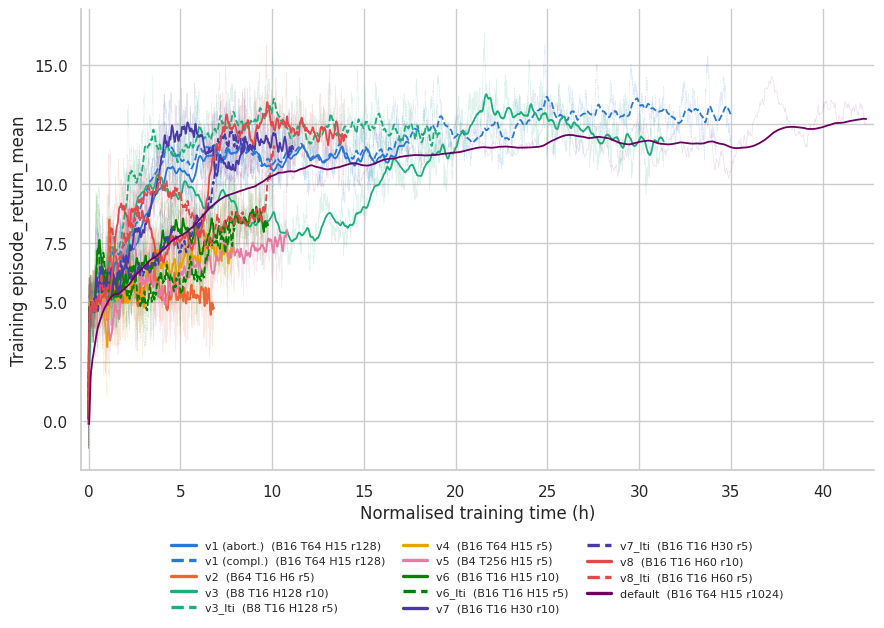

In [8]:
# y_min / y_max / x_max pin this figure and figsize re-cuts it; drop any of them to keep the
# default (SHARE_Y / TIME_LIMIT / FIGSIZE_CURVE).
plot_over_time("train", y_min=None, y_max=None, x_max=None, figsize=None)

saved /home/iai/dj0397/AdvBuildingGym/thesis_eval/2_base_bat_rbc_vs_rl/dreamerv3_snapshots_time_20260812_145058_out_3.pdf  (In-training eval return, x = progress_norm hours)


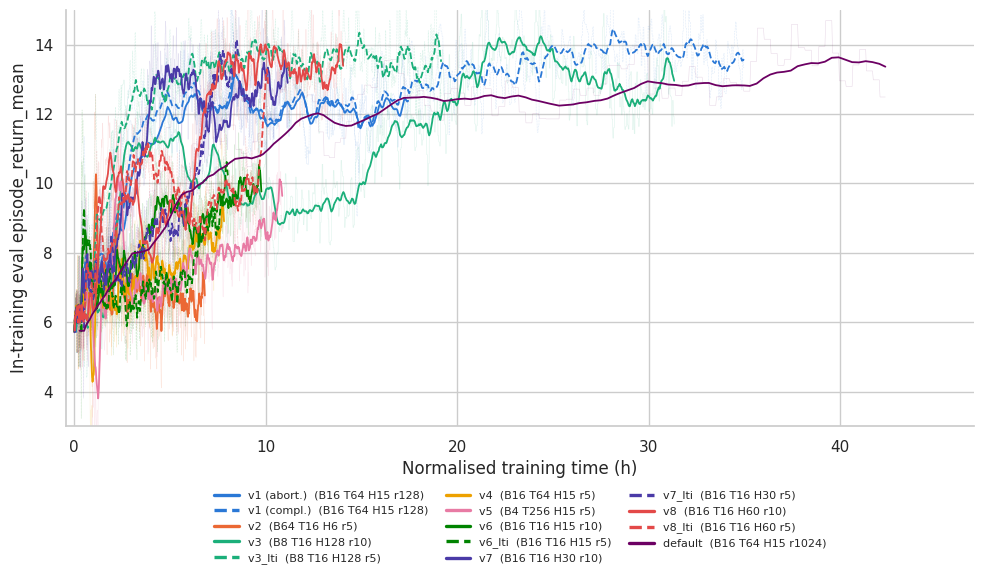

In [9]:
# Give this call the same bounds and size as the training figure to keep the two comparable.
plot_over_time("eval", y_min=3.0, y_max=15.0, x_max=47, figsize=(10, 6))

saved /home/iai/dj0397/AdvBuildingGym/thesis_eval/2_base_bat_rbc_vs_rl/dreamerv3_snapshots_time_20260812_145058_out_4.pdf  (In-training eval return, x = progress_norm hours)


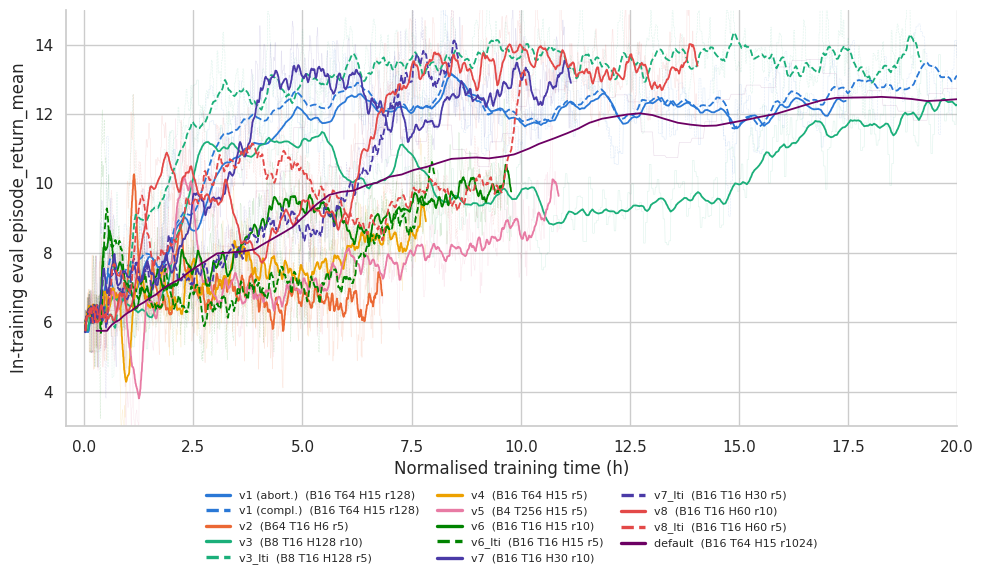

In [10]:
plot_over_time("eval", y_min=3.0, y_max=15.0, x_max=20, figsize=(10, 6))

### What the sweep costs, as configured

On the normalised axis the fourteen runs spent 6.82 h (`v2`) to 42.37 h (`default`) — and they are
not equally far along: `default` bought only 1298 iterations with its 42.37 h, `v1 (abort.)` 3359
and `v1 (compl.)` 6769, while the rest reached 6997-7000. Per iteration that is 3.51 s (`v2`) to
117.51 s (`default`), a factor of 33, so the episode axis of the sibling notebook and this one order
the sweep very differently.

`training_ratio` sets the scale of that cost at the extremes — it is how many model updates each
env step pays for — with `r128` at 18.61-18.70 s/iter and `r1024` at 117.51, far above everything
else. Between `r5` (3.51-9.86) and `r10` (5.03-16.12) the ranges overlap, because the other three
knobs are in the same term: the two `H128` runs are the slowest of their respective ratios
(`v3_lti` 9.86 at `r5`, `v3` 16.12 at `r10`), imagination horizon being the second cost driver here.

**What the correction changes.** It shortens every run — by 2.5 % (`v1`) to 52.3 % (`v2`), none of
these runs having been faster than the 1.0 ms/env-step reference — but the point is the differences,
not the totals. The single-knob pairs order the way `training_ratio` predicts only after it: on raw
wall clock `v7` (`r10`, 84 000 gradient updates) reads 6.82 s/iter against `v7_lti` (`r5`, 42 000
updates) at 7.82, i.e. the run doing twice the learner work looks cheaper, because `v7_lti` ran at a
median 1.93 ms per env step against `v7`'s 1.21. Corrected: 5.74 vs 4.41 s/iter, with the `v6`
(5.03 vs 4.13) and `v8` (7.23 vs 5.21) pairs keeping the order they already had. No pair inverts on
the normalised axis.

The `env_step_ms` columns are where that comes from: the probe's median runs from 1.02 ms (`v1`) to
2.23 ms (`v6`), and its p5-p95 spread reaches a factor of 2.3 (`v6`), 2.2 (`v2`) and 2.0 (`v7_lti`,
`v8_lti`) — those runs changed speed part-way through. A run whose p5 and p95 sit within a few per
cent of each other (`v1`, `v3`, `v6_lti`) held one speed throughout and is barely touched by the
correction, which is what a machine probe should do.

The two raw time records agree throughout: `train_hours` and `wall_hours` differ by at most 0.14 h
(`v2`, under 1 %), so choosing `"events"` over `"progress"` changes no conclusion here — the
machine correction does. `default` is the one row where `wall_hours` comes out *smaller*, because
the events axis starts at the end of iteration 1 — 141 s of that run's total, more than the
overhead the events axis adds back.

## How fast: time to reach a return level

The curves show the whole trajectory; this reduces "how fast does it learn" to one number per
configuration. A common absolute level is fixed for the whole sweep — `THRESHOLD_FRACTIONS` of
the best final smoothed `THRESHOLD_SERIES` return any snapshot reached — and each run is asked
when its **smoothed** curve gets there. Because the level is shared, the columns are directly
comparable: `h_to_0.9` is the training time to get within 10 % of the best result in the sweep, on
the `TIME_SOURCE` axis (normalised by default, so it is a machine-independent cost), and `NaN`
means the run never got there (its final return is the `final` column).

"Got there" is `CROSSING = "sustained"`: the point from which the curve never drops below the
level again. The looser `"first"` reading credits a run for a level it touched and then lost —
here it would report `v2` (`B64 T16 H6 r5`) as reaching 0.75× the best return in 1.13 h although
it ends the run at half that level, and `v5` likewise. Under `"sustained"` both correctly score
as never having reached it. The two readings coincide for every run whose curve rises
monotonically into its plateau.

`eps_to_*` is the episode count at that same crossing, i.e. the sample-efficiency reading of the
identical event — and the one column the machine correction cannot touch. The pair separates the
two ways a configuration can be fast: few episodes (sample-efficient) versus few hours
(compute-efficient). A high `training_ratio` buys the first by spending the second.

In [11]:
REFERENCE_LEVEL = max(float(record[f"smoothed_{THRESHOLD_SERIES}"][-1]) for record in records)
TARGETS = {fraction: fraction * REFERENCE_LEVEL for fraction in THRESHOLD_FRACTIONS}
if REFERENCE_LEVEL <= 0:
    print(f"WARNING: reference level {REFERENCE_LEVEL:.3f} is not positive — fractions of it are not a "
          f"meaningful ladder; set absolute levels in TARGETS instead")
print(f"Reference: best final smoothed {THRESHOLD_SERIES} return = {REFERENCE_LEVEL:.3f}")
print("Targets:   " + ", ".join(f"{fraction:g}× = {level:.3f}" for fraction, level in TARGETS.items()))
print(f"Crossing:  {CROSSING}")
print(f"Axis:      {_time_label()}")


# The point of the smoothed curve at which `level` counts as reached, as
# (elapsed time in TIME_UNIT, episodes); nan/nan when the run never reaches it under CROSSING.
# "sustained" takes the start of the final stretch that stays at or above the level, so a curve
# that peaks over it and then falls back does not score — under "first" it would. The smoothed
# curve is used either way: the raw one touches a level on a single lucky episode long before the
# policy holds it.
def _crossing(record: dict, series_name: str, level: float) -> tuple[float, float]:
    values = np.asarray(record[f"smoothed_{series_name}"])
    if CROSSING == "first":
        reached = np.flatnonzero(values >= level)
        index = int(reached[0]) if reached.size else None
    else:
        below = np.flatnonzero(values < level)
        index = int(below[-1]) + 1 if below.size else 0
        index = index if index < values.size else None
    if index is None:
        return float("nan"), float("nan")
    seconds = record["seconds"][TIME_SOURCE][series_name][index]
    steps = float(record["curves"][series_name]["step"].iloc[index])
    return seconds / TIME_DIVISOR[TIME_UNIT], steps * record["scales"]["episodes_per_step"]


speed_rows = []
for record in records:
    row = {"label": record["label"], **{key: record["params"][key] for key in PARAM_KEYS}}
    for fraction, level in TARGETS.items():
        time_to, episodes_to = _crossing(record, THRESHOLD_SERIES, level)
        row[f"h_to_{fraction:g}"] = round(time_to, 2)
        row[f"eps_to_{fraction:g}"] = round(episodes_to) if np.isfinite(episodes_to) else float("nan")
    row["final"] = round(float(record[f"smoothed_{THRESHOLD_SERIES}"][-1]), 3)
    speed_rows.append(row)

STRICTEST = f"h_to_{max(THRESHOLD_FRACTIONS):g}"
speed = pd.DataFrame(speed_rows).set_index("label").sort_values(STRICTEST, na_position="last")
speed

Reference: best final smoothed eval return = 13.591
Targets:   0.5× = 6.796, 0.75× = 10.193, 0.9× = 12.232
Crossing:  sustained
Axis:      Normalised training time (h)


,batch_size_B,batch_length_T,horizon_H,training_ratio,h_to_0.5,eps_to_0.5,h_to_0.75,eps_to_0.75,h_to_0.9,eps_to_0.9,final
label,,,,,,,,,,,
v3_lti,8,16,128,5.0,0.93,364.0,1.98,757.0,4.09,1551.0,13.505
v8,16,16,60,10.0,1.13,569.0,6.27,3100.0,6.89,3405.0,13.390
v7_lti,16,16,30,5.0,1.03,879.0,6.30,5175.0,7.08,5807.0,13.591
v7,16,16,30,10.0,0.40,260.0,3.30,2130.0,9.38,5900.0,12.897
v8_lti,16,16,60,5.0,0.60,420.0,9.63,6642.0,9.92,6845.0,12.791
v1 (compl.),16,64,15,128.0,0.48,96.0,2.80,552.0,15.78,3060.0,13.545
default,16,64,15,1024.0,1.67,60.0,7.03,251.0,16.46,568.0,13.365
v1 (abort.),16,64,15,128.0,1.15,224.0,3.01,590.0,17.16,3306.0,12.380
v3,8,16,128,10.0,1.79,403.0,15.28,3411.0,29.30,6540.0,12.958


### What it says, as configured

The reference level is `v7_lti`'s final smoothed eval return, 13.591, so the targets are 6.796 /
10.193 / 12.232. Nine of the fourteen runs hold the 0.9 level by the end, and the ranking in
normalised hours is `v3_lti` 4.09, `v8` 6.89, `v7_lti` 7.08, `v7` 9.38, `v8_lti` 9.92,
`v1 (compl.)` 15.78, `default` 16.46, `v1 (abort.)` 17.16, `v3` 29.30. `v3_lti`
(`B8 T16 H128 r5`) is therefore the one to beat: fastest to within 10 % of the best result **and**
finishing at 13.505, third-best of the sweep — the top-left corner of the trade-off panel below.
`v2`, `v4`, `v5`, `v6` and `v6_lti` never hold that level at all.

The correction changes that ranking, not just its numbers. Setting `TIME_SOURCE = "progress"`
orders the same nine `v3_lti` 4.92, `v8` 7.70, `v8_lti` 10.83, `v7` 11.24, `v7_lti` 13.66,
`v1 (compl.)` 16.13, `v1 (abort.)` 17.60, `default` 21.42, `v3` 30.20: `v7_lti` reads as the
fifth-fastest to the 0.9 level there and the third-fastest here, and `default` overtakes
`v1 (abort.)`. Only the winner is robust to the choice, which is the argument for making the
machine-corrected axis the default rather than an option.

The `h_to_*` and `eps_to_*` columns split apart exactly where `training_ratio` is largest, which is
the point of putting both in the table. At the 0.75 level `default` (`r1024`) needs 251 episodes —
the fewest in the sweep, three times fewer than `v3_lti`'s 757 — and pays 7.03 h for them against
`v3_lti`'s 1.98 h. At 0.9 the same split holds: 568 episodes / 16.46 h versus 1551 episodes /
4.09 h. Ranked by episodes the high-ratio configurations win; ranked by training time they lose by
a factor of four. Which ranking is the relevant one is a property of the experiment, not of the
data: sample efficiency matters when env steps are the scarce resource (a real building, a slow
simulator), compute time when GPU hours are.

saved /home/iai/dj0397/AdvBuildingGym/thesis_eval/2_base_bat_rbc_vs_rl/dreamerv3_snapshots_time_20260812_145058_out_5.pdf


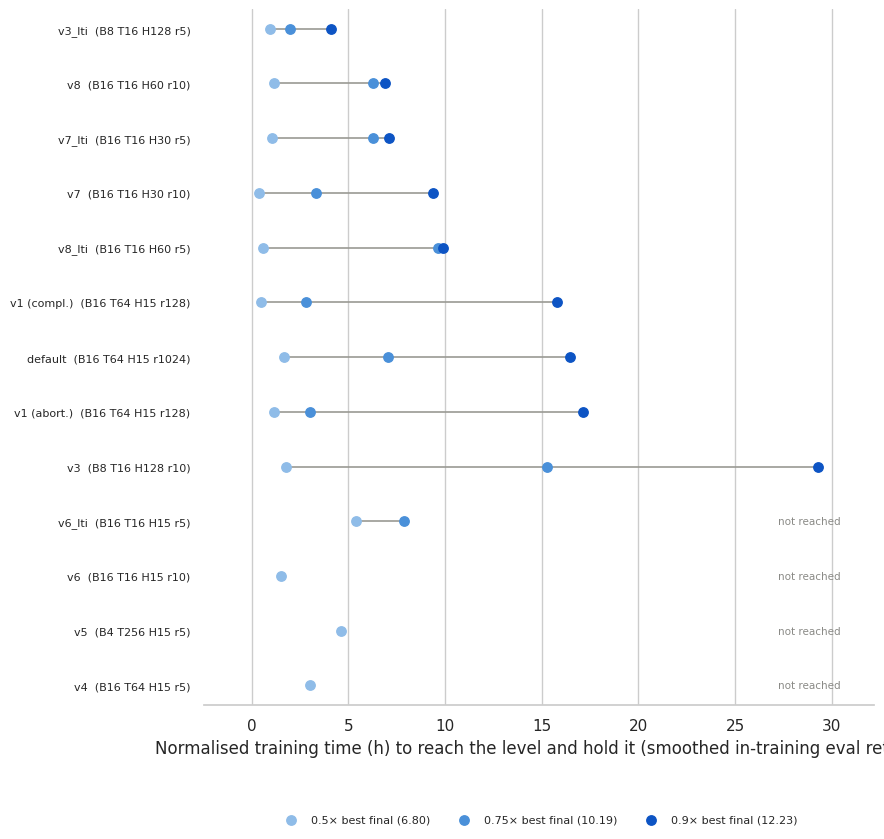

In [12]:
LEVEL_COLORS = ["#8fbce8", "#4a90d9", "#0d54c4"]  # light → dark with the level


# `figsize` overrides FIGSIZE_LEVELS for this call; a None height there (or here) is derived from
# the number of rows, so the row spacing stays readable however many snapshots are configured.
def plot_time_to_level(figsize: tuple[float, float | None] | None = None) -> None:
    ordered = speed.sort_values(STRICTEST, ascending=False, na_position="first")
    positions = np.arange(len(ordered))
    width, height = figsize or FIGSIZE_LEVELS
    fig, ax = plt.subplots(figsize=(width, height if height is not None
                                    else LEVELS_ROW_HEIGHT * len(ordered) + LEVELS_HEIGHT_PAD))

    for position, (_, row) in zip(positions, ordered.iterrows()):
        reached = [row[f"h_to_{fraction:g}"] for fraction in THRESHOLD_FRACTIONS
                   if np.isfinite(row[f"h_to_{fraction:g}"])]
        if len(reached) > 1:
            ax.plot([min(reached), max(reached)], [position, position], color="#9a9a94", linewidth=1.2, zorder=1)
    for index, fraction in enumerate(THRESHOLD_FRACTIONS):
        values = ordered[f"h_to_{fraction:g}"].to_numpy(dtype=float)
        ax.scatter(values, positions, s=46, color=LEVEL_COLORS[index % len(LEVEL_COLORS)], zorder=2,
                   label=f"{fraction:g}× best final ({TARGETS[fraction]:.2f})")

    # Runs that never reached the strictest level are named, so an empty row is not read as fast.
    for position, (_, row) in zip(positions, ordered.iterrows()):
        if not np.isfinite(row[STRICTEST]):
            ax.annotate("not reached", (ax.get_xlim()[1], position), xytext=(-4, 0), textcoords="offset points",
                        ha="right", va="center", fontsize=7.5, color="#8a8a86")

    labels = [f"{record['legend']}" for label in ordered.index
              for record in records if record["label"] == label]
    ax.set_yticks(positions)
    ax.set_yticklabels(labels, fontsize=8)
    ax.set_xlabel(f"{_time_label()} to reach the level and hold it "
                  f"(smoothed {SERIES_LABELS[THRESHOLD_SERIES].lower()})"
                  if CROSSING == "sustained" else
                  f"{_time_label()} to first reach the level "
                  f"(smoothed {SERIES_LABELS[THRESHOLD_SERIES].lower()})")
    ax.margins(x=0.10, y=0.03)
    ax.grid(axis="y", visible=False)
    ax.legend(title="", frameon=False, loc="upper center", bbox_to_anchor=(0.5, -0.10 - 0.6 / len(ordered)),
              ncol=len(THRESHOLD_FRACTIONS), fontsize=8)
    sns.despine(ax=ax, left=True)
    fig.tight_layout()

    pdf_path = next_out_path("pdf")
    fig.savefig(pdf_path, bbox_inches="tight")
    print(f"saved {pdf_path}")
    plt.show()


# figsize=(width, height) re-cuts this figure; a None height keeps the row-count-derived one.
plot_time_to_level(figsize=None)

## Speed against where it ends up

The trade-off in one panel: time to the strictest target on the x-axis, final smoothed return on
the y-axis. Bottom-left is cheap but weak, top-left is the corner worth having (fast *and* good),
top-right is strong but expensive. Runs that never reached the target carry no x value and are
listed under the figure instead of being drawn at an arbitrary position.

saved /home/iai/dj0397/AdvBuildingGym/thesis_eval/2_base_bat_rbc_vs_rl/dreamerv3_snapshots_time_20260812_145058_out_6.pdf
never reached the target, not drawn: v2  (B64 T16 H6 r5), v4  (B16 T64 H15 r5), v5  (B4 T256 H15 r5), v6  (B16 T16 H15 r10), v6_lti  (B16 T16 H15 r5)


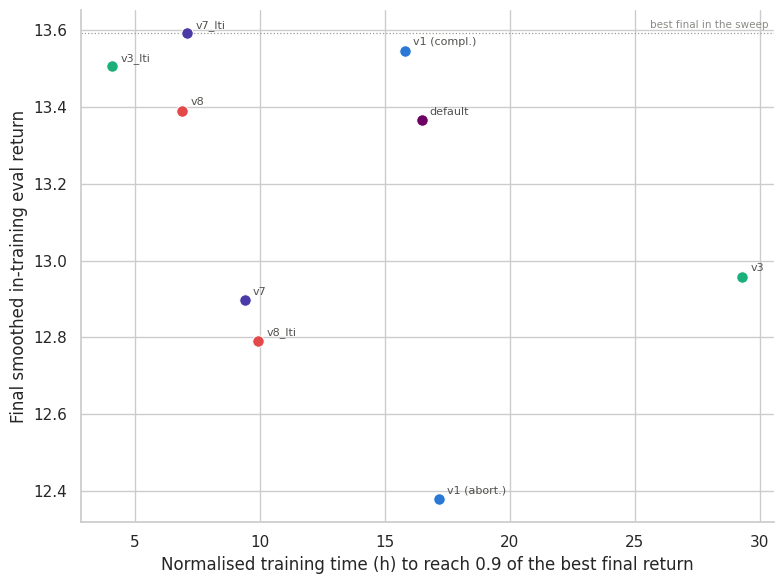

In [13]:
# `figsize` overrides FIGSIZE_SCATTER for this call.
def plot_speed_vs_quality(figsize: tuple[float, float] | None = None) -> None:
    fig, ax = plt.subplots(figsize=figsize or FIGSIZE_SCATTER)
    missing = []
    for record in records:
        row = speed.loc[record["label"]]
        if not np.isfinite(row[STRICTEST]):
            missing.append(record["legend"])
            continue
        ax.scatter(row[STRICTEST], row["final"], s=70, color=record["color"],
                   edgecolor="white", linewidth=0.8, zorder=2)
        ax.annotate(record["label"], (row[STRICTEST], row["final"]), xytext=(6, 4),
                    textcoords="offset points", fontsize=8, color="#52514e")

    ax.axhline(REFERENCE_LEVEL, color="#9a9a94", linewidth=0.9, linestyle=":", zorder=1)
    ax.annotate("best final in the sweep", (ax.get_xlim()[1], REFERENCE_LEVEL), xytext=(-4, 4),
                textcoords="offset points", ha="right", fontsize=7.5, color="#8a8a86")
    ax.set_xlabel(f"{_time_label()} to reach {max(THRESHOLD_FRACTIONS):g} of the best final return")
    ax.set_ylabel(f"Final smoothed {SERIES_LABELS[THRESHOLD_SERIES].lower()}")
    sns.despine(ax=ax)
    fig.tight_layout()

    pdf_path = next_out_path("pdf")
    fig.savefig(pdf_path, bbox_inches="tight")
    print(f"saved {pdf_path}")
    if missing:
        print("never reached the target, not drawn: " + ", ".join(missing))
    plt.show()


plot_speed_vs_quality(figsize=None)

## Cost of the sweep

`mean` / `std` / `min` / `max` of the time columns — raw wall clock next to its machine-corrected
`_norm` twin, so the size of the correction is visible in aggregate — and the same for the
time-to-target columns, which are on the `TIME_SOURCE` axis. Read against the per-episode spread in
[`sps_train_return_convergence_snapshots.ipynb`](sps_train_return_convergence_snapshots.ipynb):
where that notebook's spread is the return the knobs buy, this one is the compute they cost, and
the ratio of the two is what makes a configuration worth using.

In [14]:
cost = summary[["train_hours", "train_h_norm", "wall_hours", "s_per_iter", "s_per_iter_norm",
                "eps_per_hour", "eps_per_hour_norm", "h_per_1k_eps", "h_per_1k_eps_norm"]].agg(
    ["mean", "std", "min", "max"]).round(3)
display(cost)

time_columns = [f"h_to_{fraction:g}" for fraction in THRESHOLD_FRACTIONS]
reach = pd.DataFrame({
    "reached": speed[time_columns].notna().sum(),
    "of": len(speed),
    "fastest": speed[time_columns].min().round(2),
    "slowest": speed[time_columns].max().round(2),
    "median": speed[time_columns].median().round(2),
})
reach

,train_hours,train_h_norm,wall_hours,s_per_iter,s_per_iter_norm,eps_per_hour,eps_per_hour_norm,h_per_1k_eps,h_per_1k_eps_norm
mean,19.700,16.612,19.779,18.629,16.120,421.536,556.386,5.168,4.472
std,11.314,11.418,11.291,33.293,29.688,216.514,309.966,9.225,8.227
min,8.510,6.820,8.580,4.380,3.510,27.100,30.700,1.215,0.975
max,47.960,42.370,47.940,133.010,117.510,822.800,1025.700,36.861,32.567


,reached,of,fastest,slowest,median
h_to_0.5,13,14,0.40,5.42,1.15
h_to_0.75,10,14,1.98,15.28,6.28
h_to_0.9,9,14,4.09,29.30,9.92
